In [2]:
# All Libraries Import & Datasets Load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

contracts_df = pd.read_csv('contracts.csv')
claims_df = pd.read_csv('claims.csv')
vehicles_df = pd.read_csv('vehicles.csv')

print("Libraries imported & Datasets loaded successfully!")

print("\n--- Contracts Data ---")
display(contracts_df.head(2))

print("\n--- Claims Data ---")
display(claims_df.head(2))

print("\n--- Vehicles Data ---")
display(vehicles_df.head(2))

Libraries imported & Datasets loaded successfully!

--- Contracts Data ---


,contract_id,client_id,client_name,product,start_date,end_date,annual_premium,status,city_postal,risk_zone,client_age,channel,csp,gender
0,CTR_000001,CLI_000001,Pascal Dubois,Life,11/08/2023,2024-09-08,1974.98€,Renewed,Paris_75001,High,50.0,Agency,NaN,F
1,CTR_000002,CLI_000002,Sophie Simon,Auto,2025-08-12,2026-08-15,€620.93,Active,Bordeaux_33000,Medium,43.0,Phone,Worker,F



--- Claims Data ---


,claim_id,contract_id,occurrence_date,declaration_date,claim_type,damage_amount,indemnified_amount,status,expert_id,liability
0,CLM_0000001,CTR_008899,26-11-2023,2023-10-02,Theft,15213.03€,10977.27€,Closed,EXP_013,Third_party
1,CLM_0000002,CTR_001770,2025-08-26,2025-08-28,Fire,2321.55€,NaN,Expert_review,EXP_013,Third_party



--- Vehicles Data ---


,contract_id,brand,model,year,power,fuel_type,current_value,color,usage,previous_claims
0,CTR_000003,BMW,Serie1,2022.0,128 HP,Gasoline,29567.77€,Gray,Mixed,0.0
1,CTR_000005,Renault,Megane,2024.0,150 HP,Hybrid,14873.92€,Black,Personal,0.0


In [6]:
# Data Structure, Data Types & Missing Values Check

print("=== DATASETS SHAPE ===")
print(f"Contracts Shape: {contracts_df.shape}")
print(f"Claims Shape:    {claims_df.shape}")
print(f"Vehicles Shape:  {vehicles_df.shape}\n")

print("=== CONTRACTS INFO ===")
contracts_df.info()

print("\n=== MISSING VALUES COUNT ===")
print("Contracts Nulls:\n", contracts_df.isnull().sum()[contracts_df.isnull().sum() > 0])
print("\nClaims Nulls:\n", claims_df.isnull().sum()[claims_df.isnull().sum() > 0])
print("\nVehicles Nulls:\n", vehicles_df.isnull().sum()[vehicles_df.isnull().sum() > 0])

=== DATASETS SHAPE ===
Contracts Shape: (15000, 14)
Claims Shape:    (155, 10)
Vehicles Shape:  (5390, 10)

=== CONTRACTS INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   contract_id     15000 non-null  str    
 1   client_id       15000 non-null  str    
 2   client_name     15000 non-null  str    
 3   product         15000 non-null  str    
 4   start_date      15000 non-null  str    
 5   end_date        15000 non-null  str    
 6   annual_premium  15000 non-null  str    
 7   status          15000 non-null  str    
 8   city_postal     15000 non-null  str    
 9   risk_zone       15000 non-null  str    
 10  client_age      13735 non-null  float64
 11  channel         15000 non-null  str    
 12  csp             13228 non-null  str    
 13  gender          11904 non-null  str    
dtypes: float64(1), str(13)
memory usage: 1.6 MB

=

In [12]:
# Helper function to clean currency columns
def clean_currency(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).replace('€', '').replace('$', '').replace('EUR', '').replace(',', '').strip()
    try:
        return float(val_str)
    except ValueError:
        return np.nan

# --- 1. Clean Contracts DataFrame ---
contracts_df['annual_premium'] = contracts_df['annual_premium'].apply(clean_currency)
contracts_df['start_date'] = pd.to_datetime(contracts_df['start_date'], dayfirst=True, errors='coerce')
contracts_df['end_date'] = pd.to_datetime(contracts_df['end_date'], dayfirst=True, errors='coerce')

# Impute missing values
contracts_df['client_age'] = contracts_df['client_age'].fillna(contracts_df['client_age'].median()).astype(int)
contracts_df['csp'] = contracts_df['csp'].fillna('Unknown')
contracts_df['gender'] = contracts_df['gender'].fillna('Unspecified')
contracts_df['risk_zone'] = contracts_df['risk_zone'].fillna('Medium')


# --- 2. Clean Claims DataFrame ---
claims_df['damage_amount'] = claims_df['damage_amount'].apply(clean_currency)
claims_df['indemnified_amount'] = claims_df['indemnified_amount'].apply(clean_currency).fillna(0.0)
claims_df['occurrence_date'] = pd.to_datetime(claims_df['occurrence_date'], dayfirst=True, errors='coerce')
claims_df['declaration_date'] = pd.to_datetime(claims_df['declaration_date'], dayfirst=True, errors='coerce')

# Impute missing values
claims_df['liability'] = claims_df['liability'].fillna('Pending_Evaluation')
claims_df['expert_id'] = claims_df['expert_id'].fillna('Unassigned')


# --- 3. Clean Vehicles DataFrame ---
vehicles_df['current_value'] = vehicles_df['current_value'].apply(clean_currency)

# Extract numbers only if 'power' column exists in dataframe
if 'power' in vehicles_df.columns:
    vehicles_df['power_hp'] = vehicles_df['power'].astype(str).str.extract(r'(\d+)').astype(float)
    vehicles_df['power_hp'] = vehicles_df['power_hp'].fillna(vehicles_df['power_hp'].median()).astype(int)
    vehicles_df.drop(columns=['power'], inplace=True, errors='ignore')

# Impute missing values
vehicles_df['year'] = vehicles_df['year'].fillna(vehicles_df['year'].median()).astype(int)
vehicles_df['color'] = vehicles_df['color'].fillna('Unknown')
vehicles_df['previous_claims'] = vehicles_df['previous_claims'].fillna(0).astype(int)

print("Data Cleaning & Imputation Completed Successfully!")

Data Cleaning & Imputation Completed Successfully!


In [14]:
print("=== CONTRACTS NULLS BY COLUMN ===")
print(contracts_df.isnull().sum()[contracts_df.isnull().sum() > 0])

print("\n=== CLAIMS NULLS BY COLUMN ===")
print(claims_df.isnull().sum()[claims_df.isnull().sum() > 0])

print("\n=== VEHICLES NULLS BY COLUMN ===")
print(vehicles_df.isnull().sum()[vehicles_df.isnull().sum() > 0])

=== CONTRACTS NULLS BY COLUMN ===
start_date        13965
end_date          10026
annual_premium      778
dtype: int64

=== CLAIMS NULLS BY COLUMN ===
occurrence_date     146
declaration_date    106
damage_amount        10
dtype: int64

=== VEHICLES NULLS BY COLUMN ===
current_value    294
dtype: int64


In [16]:
# --- 1. Contracts Imputation ---
for col in contracts_df.columns:
    if pd.api.types.is_numeric_dtype(contracts_df[col]):
        contracts_df[col] = contracts_df[col].fillna(contracts_df[col].median())
    elif pd.api.types.is_datetime64_any_dtype(contracts_df[col]):
        contracts_df[col] = contracts_df[col].fillna(contracts_df[col].mode()[0])
    else:
        contracts_df[col] = contracts_df[col].fillna('Unknown')

# --- 2. Claims Imputation ---
for col in claims_df.columns:
    if pd.api.types.is_numeric_dtype(claims_df[col]):
        claims_df[col] = claims_df[col].fillna(0)
    elif pd.api.types.is_datetime64_any_dtype(claims_df[col]):
        claims_df[col] = claims_df[col].fillna(claims_df[col].mode()[0])
    else:
        claims_df[col] = claims_df[col].fillna('Unknown')

# --- 3. Vehicles Imputation ---
for col in vehicles_df.columns:
    if pd.api.types.is_numeric_dtype(vehicles_df[col]):
        vehicles_df[col] = vehicles_df[col].fillna(vehicles_df[col].median())
    elif pd.api.types.is_datetime64_any_dtype(vehicles_df[col]):
        vehicles_df[col] = vehicles_df[col].fillna(vehicles_df[col].mode()[0])
    else:
        vehicles_df[col] = vehicles_df[col].fillna('Unknown')

# Final Verification
print("=== FINAL NULL VALUES CHECK ===")
print("Contracts Nulls Remaining:", contracts_df.isnull().sum().sum())
print("Claims Nulls Remaining:   ", claims_df.isnull().sum().sum())
print("Vehicles Nulls Remaining: ", vehicles_df.isnull().sum().sum())

=== FINAL NULL VALUES CHECK ===
Contracts Nulls Remaining: 0
Claims Nulls Remaining:    0
Vehicles Nulls Remaining:  0


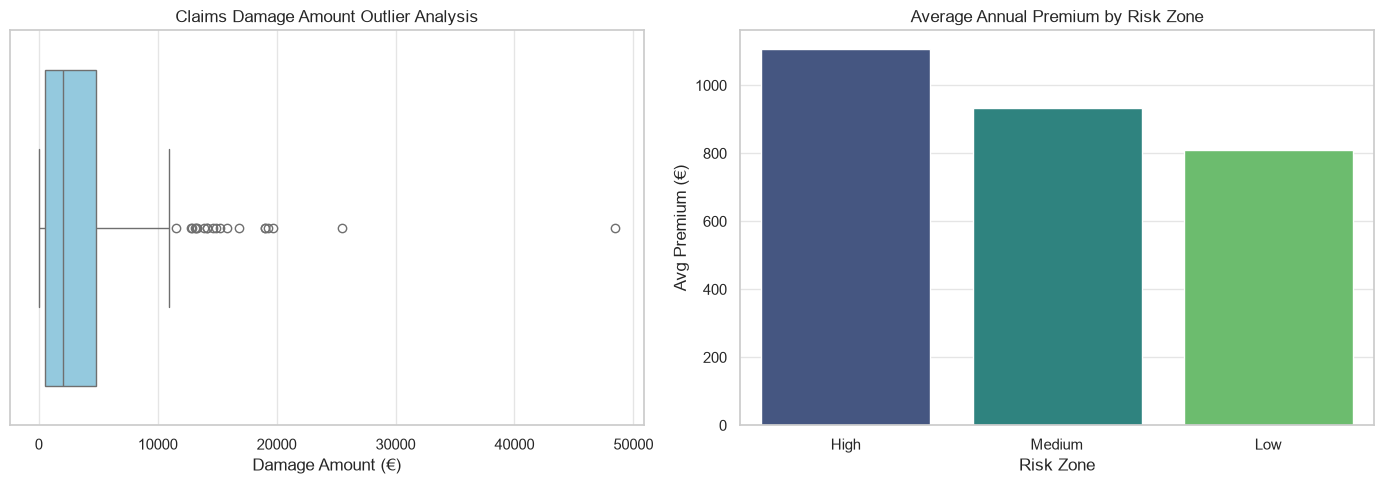

In [18]:
# Setup figure for 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Boxplot for Claims Damage Amount
sns.boxplot(x=claims_df['damage_amount'], ax=axes[0], color='skyblue')
axes[0].set_title('Claims Damage Amount Outlier Analysis')
axes[0].set_xlabel('Damage Amount (€)')

# Plot 2: Bar Plot for Average Premium by Risk Zone (Warning Fixed)
sns.barplot(data=contracts_df, x='risk_zone', y='annual_premium', ax=axes[1], hue='risk_zone', palette='viridis', legend=False, errorbar=None)
axes[1].set_title('Average Annual Premium by Risk Zone')
axes[1].set_xlabel('Risk Zone')
axes[1].set_ylabel('Avg Premium (€)')

plt.tight_layout()
plt.show()

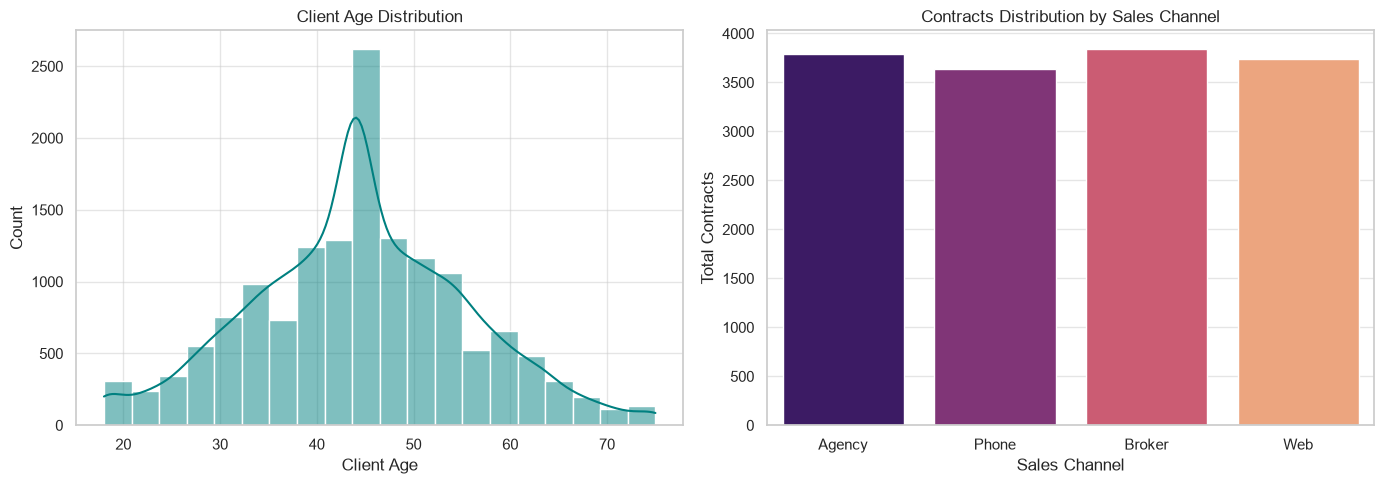

In [19]:
# Setup figure for 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Age Distribution of Clients
sns.histplot(contracts_df['client_age'], kde=True, ax=axes[0], color='teal', bins=20)
axes[0].set_title('Client Age Distribution')
axes[0].set_xlabel('Client Age')
axes[0].set_ylabel('Count')

# Plot 2: Contract Count by Channel
sns.countplot(data=contracts_df, x='channel', hue='channel', ax=axes[1], palette='magma', legend=False)
axes[1].set_title('Contracts Distribution by Sales Channel')
axes[1].set_xlabel('Sales Channel')
axes[1].set_ylabel('Total Contracts')

plt.tight_layout()
plt.show()

In [20]:
# 1. Merge Contracts and Claims on contract_id
master_df = pd.merge(contracts_df, claims_df, on='contract_id', how='left')

# 2. Merge Vehicles data into the Master DataFrame
# Checking common key between contracts/claims and vehicles
vehicle_key = 'contract_id' if 'contract_id' in vehicles_df.columns else 'client_id'
master_df = pd.merge(master_df, vehicles_df, on=vehicle_key, how='left')

# Fill NaN values created due to outer/left join (for contracts without claims)
master_df['damage_amount'] = master_df['damage_amount'].fillna(0)
master_df['indemnified_amount'] = master_df['indemnified_amount'].fillna(0)
master_df['has_claim'] = np.where(master_df['claim_id'].isna(), 0, 1)

print("=== MASTER DATAFRAME CREATED SUCCESSFULLY ===")
print("Master DF Shape:", master_df.shape)
print("\nFirst 3 rows of Master DF:")
display(master_df.head(3))

=== MASTER DATAFRAME CREATED SUCCESSFULLY ===
Master DF Shape: (15000, 33)

First 3 rows of Master DF:


,contract_id,client_id,client_name,product,start_date,end_date,annual_premium,status_x,city_postal,risk_zone,...,brand,model,year,fuel_type,current_value,color,usage,previous_claims,power_hp,has_claim
0,CTR_000001,CLI_000001,Pascal Dubois,Life,2023-08-11,2024-08-09,1974.98,Renewed,Paris_75001,High,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,CTR_000002,CLI_000002,Sophie Simon,Auto,2023-03-05,2025-05-10,620.93,Active,Bordeaux_33000,Medium,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,CTR_000003,CLI_000003,Olivier Durand,Auto,2023-03-05,2025-05-10,1568.11,Suspended,Paris_75001,High,...,BMW,Serie1,2022.0,Gasoline,29567.77,Gray,Mixed,0.0,128.0,0


In [21]:
# Clean up duplicate status columns if created during merge
if 'status_x' in master_df.columns:
    master_df.rename(columns={'status_x': 'contract_status'}, inplace=True)
if 'status_y' in master_df.columns:
    master_df.drop(columns=['status_y'], inplace=True, errors='ignore')

# 1. Total Metrics
total_premium = master_df['annual_premium'].sum()
total_claims_paid = master_df['indemnified_amount'].sum()
total_damage = master_df['damage_amount'].sum()
total_contracts = master_df['contract_id'].nunique()
total_claims_count = master_df['has_claim'].sum()

# 2. Key Business Ratios
overall_loss_ratio = (total_claims_paid / total_premium) * 100
avg_claim_severity = master_df[master_df['has_claim'] == 1]['damage_amount'].mean()
claim_frequency_pct = (total_claims_count / total_contracts) * 100

print("=== EXECUTIVE INSURANCE KPIs SUMMARY ===")
print(f"Total Written Premium : €{total_premium:,.2f}")
print(f"Total Claims Paid     : €{total_claims_paid:,.2f}")
print(f"Total Damage Amount   : €{total_damage:,.2f}")
print(f"Overall Loss Ratio    : {overall_loss_ratio:.2f}%")
print(f"Claim Frequency Rate  : {claim_frequency_pct:.2f}%")
print(f"Avg Claim Severity    : €{avg_claim_severity:,.2f}")

=== EXECUTIVE INSURANCE KPIs SUMMARY ===
Total Written Premium : €14,194,776.40
Total Claims Paid     : €219,909.27
Total Damage Amount   : €657,606.73
Overall Loss Ratio    : 1.55%
Claim Frequency Rate  : 1.03%
Avg Claim Severity    : €4,242.62


In [23]:
# Grouping by Product & Risk Zone to calculate Loss Ratios
risk_product_summary = master_df.groupby(['product', 'risk_zone']).agg(
    Total_Contracts=('contract_id', 'nunique'),
    Total_Premium=('annual_premium', 'sum'),
    Total_Claims_Paid=('indemnified_amount', 'sum'),
    Total_Damage=('damage_amount', 'sum'),
    Claim_Count=('has_claim', 'sum')
).reset_index()

# Calculate specific Loss Ratio per group
risk_product_summary['Loss_Ratio_%'] = (risk_product_summary['Total_Claims_Paid'] / risk_product_summary['Total_Premium']) * 100
risk_product_summary['Loss_Ratio_%'] = risk_product_summary['Loss_Ratio_%'].round(2)

print("=== RISK ZONE & PRODUCT LOSS RATIO BREAKDOWN ===")
display(risk_product_summary.sort_values(by='Loss_Ratio_%', ascending=False))

=== RISK ZONE & PRODUCT LOSS RATIO BREAKDOWN ===


,product,risk_zone,Total_Contracts,Total_Premium,Total_Claims_Paid,Total_Damage,Claim_Count,Loss_Ratio_%
1,Auto,Low,1887,1176003.140,84173.58,189250.07,44,7.16
7,Home,Low,1248,409108.175,28048.95,32044.13,3,6.86
6,Home,High,1286,743073.580,23377.02,33726.10,4,3.15
2,Auto,Medium,2702,2213535.580,55930.60,184587.07,54,2.53
0,Auto,High,1757,2000967.635,20436.01,118438.78,38,1.02
8,Home,Medium,1872,790499.055,7943.11,99560.58,12,1.00
3,Health,High,469,635730.810,0.00,0.00,0,0.00
5,Health,Medium,738,983737.495,0.00,0.00,0,0.00
4,Health,Low,478,652772.700,0.00,0.00,0,0.00
9,Life,High,736,1318623.550,0.00,0.00,0,0.00


=== RISK ZONE & PRODUCT LOSS RATIO BREAKDOWN ===
product risk_zone  Total_Contracts  Total_Premium  Total_Claims_Paid  Total_Damage  Claim_Count  Loss_Ratio_%
   Auto       Low             1887    1176003.140           84173.58     189250.07           44          7.16
   Home       Low             1248     409108.175           28048.95      32044.13            3          6.86
   Home      High             1286     743073.580           23377.02      33726.10            4          3.15
   Auto    Medium             2702    2213535.580           55930.60     184587.07           54          2.53
   Auto      High             1757    2000967.635           20436.01     118438.78           38          1.02
   Home    Medium             1872     790499.055            7943.11      99560.58           12          1.00
 Health      High              469     635730.810               0.00          0.00            0          0.00
 Health    Medium              738     983737.495               0.00   

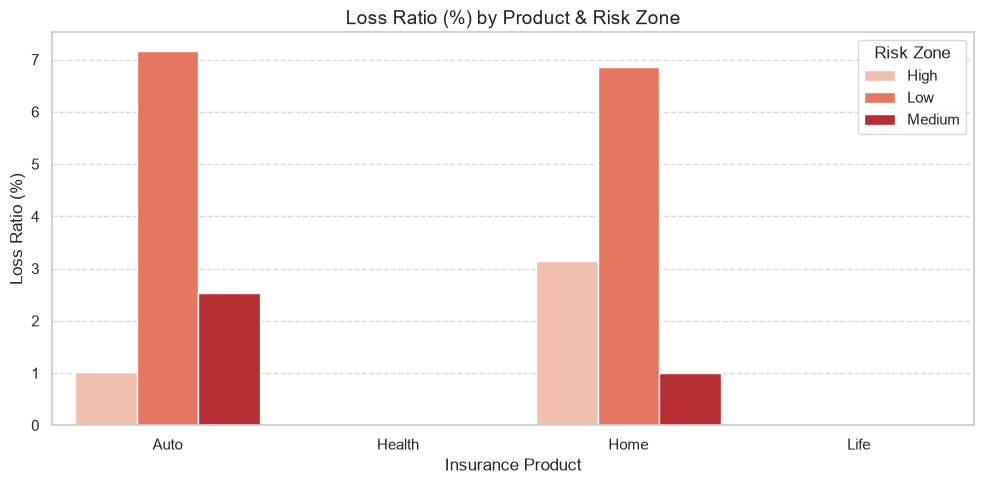


Success: Final 'insurance_analytics_master_data.csv' exported for Power BI / Dashboard analysis!


In [25]:
# 1. Force Display Summary Table
print("=== RISK ZONE & PRODUCT LOSS RATIO BREAKDOWN ===")
print(risk_product_summary.sort_values(by='Loss_Ratio_%', ascending=False).to_string(index=False))
print("\n" + "="*50 + "\n")

# 2. Visualizing Loss Ratio across Products and Risk Zones
plt.figure(figsize=(10, 5))
sns.barplot(
    data=risk_product_summary,
    x='product',
    y='Loss_Ratio_%',
    hue='risk_zone',
    palette='Reds'
)
plt.title('Loss Ratio (%) by Product & Risk Zone', fontsize=14)
plt.xlabel('Insurance Product')
plt.ylabel('Loss Ratio (%)')
plt.legend(title='Risk Zone')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Export Master Cleaned Dataset for Dashboard (Power BI / Excel)
master_df.to_csv('insurance_analytics_master_data.csv', index=False)
print("\nSuccess: Final 'insurance_analytics_master_data.csv' exported for Power BI / Dashboard analysis!")

In [26]:
# 1. Export Master Cleaned Dataset for Power BI
master_df.to_csv('insurance_analytics_master_data.csv', index=False)

# 2. Export Loss Ratio Summary Table for Executive Reporting
risk_product_summary.to_csv('risk_product_loss_ratio_summary.csv', index=False)

print("=== ALL FILES EXPORTED SUCCESSFULLY ===")
print("1. insurance_analytics_master_data.csv")
print("2. risk_product_loss_ratio_summary.csv")
print("3. clean_contracts.csv")
print("4. clean_claims.csv")
print("5. clean_vehicles.csv")

=== ALL FILES EXPORTED SUCCESSFULLY ===
1. insurance_analytics_master_data.csv
2. risk_product_loss_ratio_summary.csv
3. clean_contracts.csv
4. clean_claims.csv
5. clean_vehicles.csv


In [27]:
# Exporting individually cleaned dataframes
contracts_df.to_csv('clean_contracts.csv', index=False)
claims_df.to_csv('clean_claims.csv', index=False)
vehicles_df.to_csv('clean_vehicles.csv', index=False)

print("=== INDIVIDUAL CLEANED FILES EXPORTED SUCCESSFULLY ===")
print("1. clean_contracts.csv")
print("2. clean_claims.csv")
print("3. clean_vehicles.csv")

=== INDIVIDUAL CLEANED FILES EXPORTED SUCCESSFULLY ===
1. clean_contracts.csv
2. clean_claims.csv
3. clean_vehicles.csv
